# Standard Deep Neural Network (DNN) - Diabetes Dataset

This notebook trains a standard (non-private) DNN classifier on the BRFSS 2015 Diabetes dataset.

---

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Scikit-learn metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

# Device selection
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print(f"Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


Using CPU
PyTorch version: 2.11.0
Device: cpu


## 2. Load Preprocessed Data

In [2]:
# Load the preprocessed data
with open("../data/processed_data.pkl", "rb") as f:
    loaded_data = pickle.load(f)

X_train = loaded_data["X_train"]
X_test = loaded_data["X_test"]
y_train = loaded_data["y_train"]
y_test = loaded_data["y_test"]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoaders
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✓ Data loaded and prepared")

Training set: (56553, 21)
Test set: (14139, 21)
Number of features: 21

Class distribution in training set:
1.0    28277
0.0    28276
Name: count, dtype: int64

✓ Data loaded and prepared


## 3. Define DNN Architecture

In [3]:
class DNNClassifier(nn.Module):
    def __init__(self, input_size=21, hidden_sizes=[64, 32], num_classes=2, dropout=0.3):
        super(DNNClassifier, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Hyperparameters
input_size = X_train.shape[1]
hidden_sizes = [64, 32]
num_classes = 2
dropout = 0.3
learning_rate = 0.001
num_epochs = 50

print(f"Model Architecture:")
print(f"  Input: {input_size} features")
print(f"  Hidden layers: {hidden_sizes}")
print(f"  Output: {num_classes} classes")
print(f"  Dropout: {dropout}")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {num_epochs}")

Model Architecture:
  Input: 21 features
  Hidden layers: [64, 32]
  Output: 2 classes
  Dropout: 0.3
  Learning rate: 0.001
  Epochs: 50


## 4. Training Functions

In [4]:
def train_model(model, train_loader, criterion, optimizer, num_epochs, device, verbose=False):
    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    return train_losses

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("✓ Training functions defined")

✓ Training functions defined


## 5. Train Standard DNN (30 Runs)

In [5]:
N_RUNS = 10

detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_roc_auc = []
detail_cms = []

print(f"Training Standard DNN {N_RUNS} times...")
print("="*80)

extra = ExtraMetrics()
for run in range(N_RUNS):
    seed = run * 10 + 42
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    model = DNNClassifier(input_size, hidden_sizes, num_classes, dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    _t0 = time.perf_counter()
    train_losses = train_model(model, train_loader, criterion, optimizer, num_epochs, device)
    train_time = time.perf_counter() - _t0
    # Training-partition score for the non-private fit.
    y_train_true, y_train_pred, _ = evaluate_model(model, train_loader, device)
    y_true, y_pred, y_prob = evaluate_model(model, test_loader, device)

    accuracy = accuracy_score(y_true, y_pred)
    extra.add(y_true, y_pred, y_score=y_prob, train_true=y_train_true, train_pred=y_train_pred, train_time=train_time)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    detail_accuracies.append(accuracy)
    detail_f1s.append(f1)
    detail_precisions.append(precision)
    detail_recalls.append(recall)
    detail_roc_auc.append(roc_auc)
    detail_cms.append(cm)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {accuracy:.4f} | F1: {f1:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f}")

print("="*80)
print("✓ Training complete")

Training Standard DNN 10 times...


  Run  1/10 | Acc: 0.7508 | F1: 0.7600 | Prec: 0.7328 | Rec: 0.7894


  Run  2/10 | Acc: 0.7504 | F1: 0.7645 | Prec: 0.7235 | Rec: 0.8104


  Run  3/10 | Acc: 0.7522 | F1: 0.7643 | Prec: 0.7286 | Rec: 0.8038


  Run  4/10 | Acc: 0.7517 | F1: 0.7673 | Prec: 0.7219 | Rec: 0.8188


...

  Run  6/10 | Acc: 0.7515 | F1: 0.7678 | Prec: 0.7205 | Rec: 0.8218


  Run  7/10 | Acc: 0.7515 | F1: 0.7644 | Prec: 0.7265 | Rec: 0.8065


  Run  8/10 | Acc: 0.7510 | F1: 0.7664 | Prec: 0.7218 | Rec: 0.8169


  Run  9/10 | Acc: 0.7525 | F1: 0.7604 | Prec: 0.7369 | Rec: 0.7854


  Run 10/10 | Acc: 0.7508 | F1: 0.7670 | Prec: 0.7201 | Rec: 0.8205
✓ Training complete


In [6]:
# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model

export_model(model, 'output/model/std_dnn_model.pkl')

PyTorch model successfully exported to output/model/std_dnn_model.pkl


## 6. Evaluation Results

In [7]:
accuracy = float(np.mean(detail_accuracies))
f1 = float(np.mean(detail_f1s))
precision = float(np.mean(detail_precisions))
recall = float(np.mean(detail_recalls))
roc_auc = float(np.mean(detail_roc_auc))

std_accuracy = float(np.std(detail_accuracies))
std_f1 = float(np.std(detail_f1s))

print("=" * 60)
print("STANDARD DNN - EVALUATION METRICS (DIABETES DATASET)")
print("=" * 60)
print(f"Runs:      {N_RUNS}")
print(f"Accuracy:  {accuracy:.4f} ± {std_accuracy:.4f}")
print(f"F1-Score:  {f1:.4f} ± {std_f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("=" * 60)

STANDARD DNN - EVALUATION METRICS (DIABETES DATASET)
Runs:      10
Accuracy:  0.7512 ± 0.0007
F1-Score:  0.7650 ± 0.0027
Precision: 0.7250
Recall:    0.8098
ROC-AUC:   0.8293


## 7. Confusion Matrix

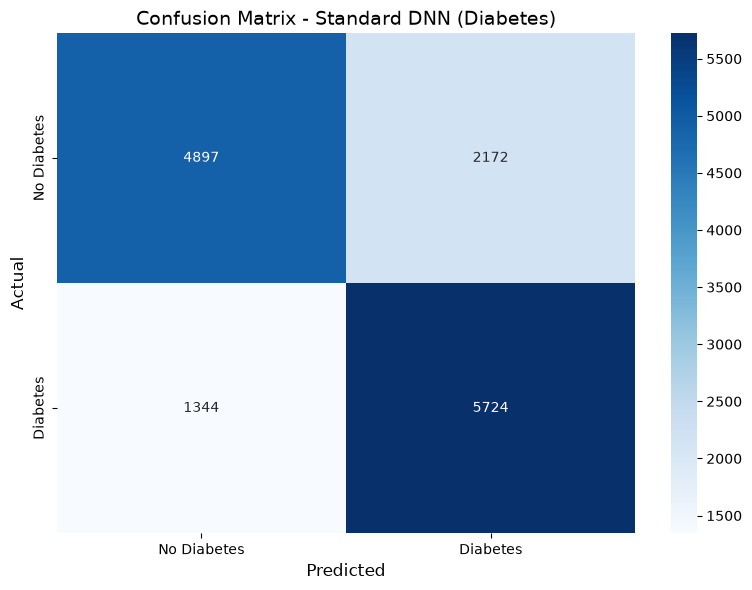


Average Confusion Matrix:
[[4897 2172]
 [1344 5724]]


In [8]:
# Average confusion matrix
avg_cm = np.mean(detail_cms, axis=0).astype(int)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Standard DNN (Diabetes)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('output/std_dnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAverage Confusion Matrix:")
print(avg_cm)

## 8. Save Baseline Results

In [9]:
import os
os.makedirs('output', exist_ok=True)

# Save baseline for comparison with DP-DNN
baseline_results = {
    'model': 'Standard DNN',
    'dataset': 'BRFSS 2015 Diabetes',
    'architecture': str(hidden_sizes),
    'input_features': input_size,
    'accuracy': accuracy,
    'f1_score': f1,
    'precision': precision,
    'recall': recall,
    'roc_auc': roc_auc,
    'accuracy_std': std_accuracy,
    'f1_std': std_f1
}
baseline_results.update(extra.means())

baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv('output/baseline_dnn_results.csv', index=False)

# Also save JSON report
parameters = {
    "architecture": "DNN",
    "input_size": input_size,
    "hidden_sizes": hidden_sizes,
    "num_classes": num_classes,
    "dropout": dropout,
    "learning_rate": learning_rate,
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "optimizer": "Adam",
    "n_runs": N_RUNS
}

results_json = {
    "model_type": "Standard DNN",
    "dataset": "BRFSS 2015 Diabetes",
    "accuracy": accuracy,
    "accuracy_std": std_accuracy,
    "f1_score": f1,
    "f1_std": std_f1,
    "precision": precision,
    "recall": recall,
    "roc_auc": roc_auc,
    "confusion_matrix": avg_cm.tolist(),
    "parameters": parameters
}
results_json.update(extra.means())

with open('output/std_dnn_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("✓ Results saved to 'output/baseline_dnn_results.csv' and 'output/std_dnn_report.json'")
print("\nBaseline Summary:")
print(baseline_df)

print("Added metrics:")
print(extra.describe())

✓ Results saved to 'output/baseline_dnn_results.csv' and 'output/std_dnn_report.json'

Baseline Summary:
          model              dataset architecture  input_features  accuracy  \
0  Standard DNN  BRFSS 2015 Diabetes     [64, 32]              21  0.751241   

   f1_score  precision    recall   roc_auc  accuracy_std    f1_std  \
0  0.764952   0.725026  0.809775  0.829345      0.000747  0.002677   

   train_accuracy  balanced_accuracy  train_time  
0        0.759196           0.751245    6.067574  
Added metrics:
  Train Acc:      0.7592 ± 0.0008
  Balanced Acc:   0.7512 ± 0.0007
  AUROC:          0.8293 ± 0.0005
  Train Time (s): 6.0676 ± 0.2004


## 9. Distribution of Metrics Across Runs

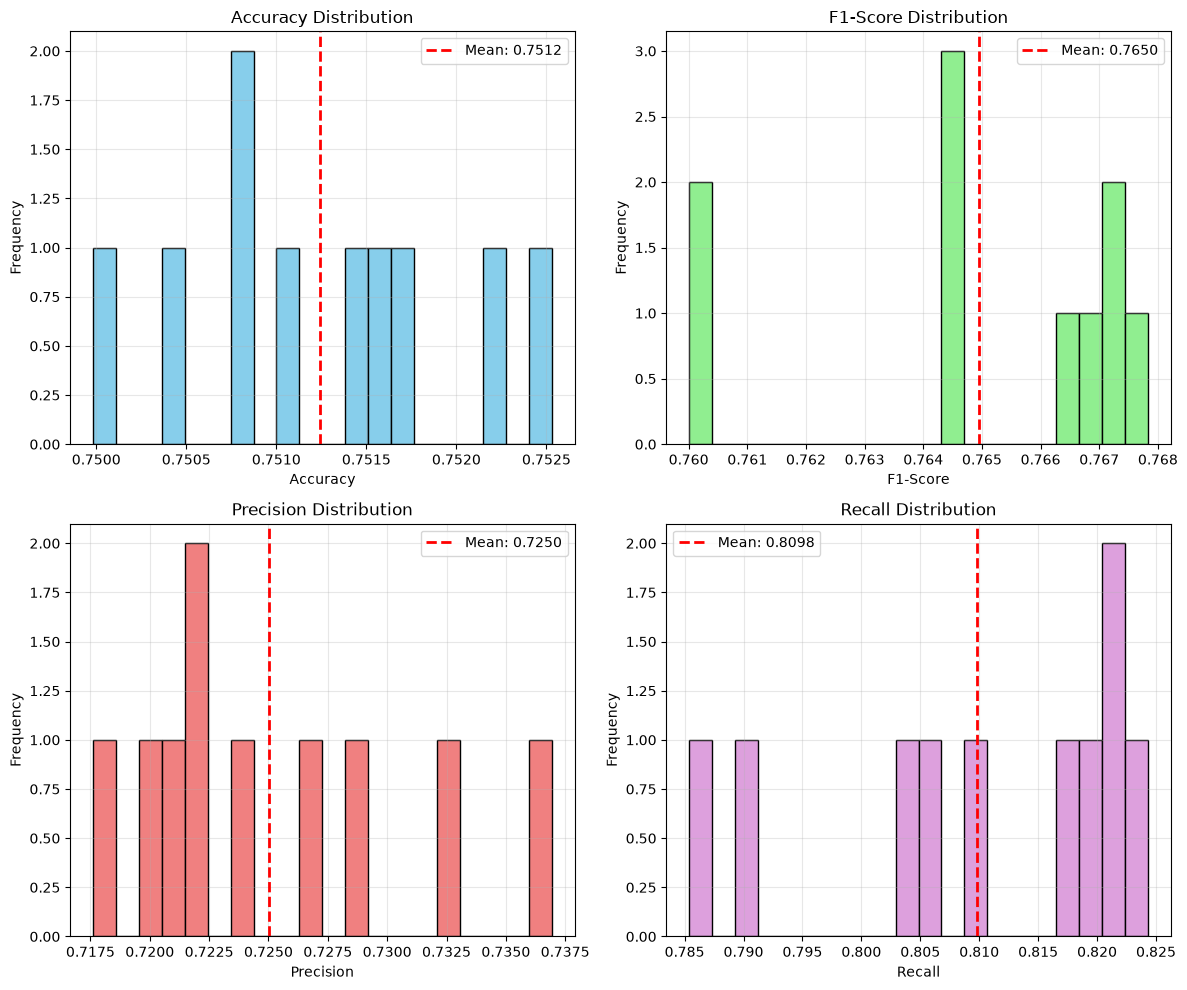

✓ Metrics distribution plotted


In [10]:
# Plot distribution of metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Accuracy
axes[0, 0].hist(detail_accuracies, bins=20, color='skyblue', edgecolor='black')
axes[0, 0].axvline(accuracy, color='red', linestyle='--', linewidth=2, label=f'Mean: {accuracy:.4f}')
axes[0, 0].set_title('Accuracy Distribution', fontsize=12)
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# F1-Score
axes[0, 1].hist(detail_f1s, bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].axvline(f1, color='red', linestyle='--', linewidth=2, label=f'Mean: {f1:.4f}')
axes[0, 1].set_title('F1-Score Distribution', fontsize=12)
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision
axes[1, 0].hist(detail_precisions, bins=20, color='lightcoral', edgecolor='black')
axes[1, 0].axvline(precision, color='red', linestyle='--', linewidth=2, label=f'Mean: {precision:.4f}')
axes[1, 0].set_title('Precision Distribution', fontsize=12)
axes[1, 0].set_xlabel('Precision')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Recall
axes[1, 1].hist(detail_recalls, bins=20, color='plum', edgecolor='black')
axes[1, 1].axvline(recall, color='red', linestyle='--', linewidth=2, label=f'Mean: {recall:.4f}')
axes[1, 1].set_title('Recall Distribution', fontsize=12)
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/std_dnn_metrics_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Metrics distribution plotted")

## 10. Summary

This notebook established the baseline performance for a standard (non-private) DNN on the BRFSS 2015 Diabetes dataset. The results will be used for comparison with the differentially private DNN in `DP_DNN.ipynb`.